# Notebook 03: Fine-Tuned Model Evaluation

Evaluates `sports-sentiment-roberta` (fine-tuned on ~2,050 turns) against the three
off-the-shelf baselines from Phase 2 on the 50-turn hand-labeled seed set.

Sections:
1. Training curves from MLflow (loss + accuracy per epoch)
2. Accuracy comparison table: fine-tuned vs 3 baselines
3. Confusion matrices side-by-side
4. Error analysis: what does the fine-tuned model still miss?
5. Five failure examples with text + predicted vs gold label

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mlflow
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from transformers import pipeline

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../models/fine-tuned-sports-sentiment")

LABEL_ORDER = ["NEGATIVE", "NEUTRAL", "POSITIVE"]

# Label normalization for baseline models (copied from src/nlp/sentiment.py)
_LABEL_MAP = {
    "cardiffnlp/twitter-roberta-base-sentiment": {
        "LABEL_0": "NEGATIVE", "LABEL_1": "NEUTRAL", "LABEL_2": "POSITIVE"
    },
    "ProsusAI/finbert": {
        "positive": "POSITIVE", "negative": "NEGATIVE", "neutral": "NEUTRAL"
    },
    "distilbert-base-uncased-finetuned-sst-2-english": {
        "POSITIVE": "POSITIVE", "NEGATIVE": "NEGATIVE"
    },
}

seed = pd.read_csv(PROCESSED_DIR / "labels_seed.csv")
print(f"Seed set: {len(seed)} turns")
print(seed["label"].value_counts().to_string())

/Users/egedenizpekel/ForkDefault/portfolio-projects/press-conference-sentiment-analyzer/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Seed set: 50 turns
label
POSITIVE    26
NEUTRAL     15
NEGATIVE     9


## 1. Training Curves from MLflow

Using run: 41276e8085bc4bc69be0ee689b090225
Params: {'warmup_ratio': '0.1', 'weight_decay': '0.01', 'train_size': '1640', 'epochs': '5', 'model': 'cardiffnlp/twitter-roberta-base-sentiment', 'batch_size': '16', 'lr': '2e-05', 'val_size': '410', 'max_length': '256'}


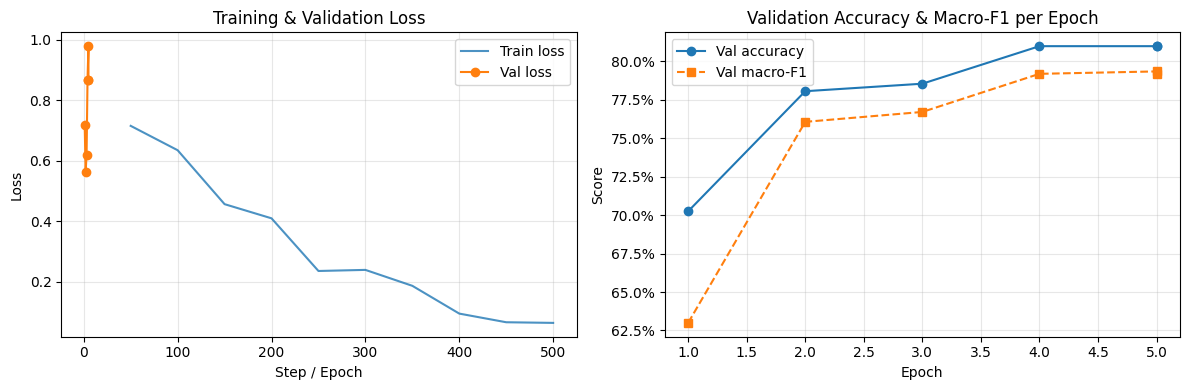

Saved: 03_training_curves.png


In [2]:

# Point to the project-root mlruns so the notebook works regardless of execution directory
mlflow.set_tracking_uri(str(Path("../mlruns").resolve()))
mlflow.set_experiment("sports-sentiment-finetuning")
client = mlflow.tracking.MlflowClient()

# Find most recent completed run
runs = client.search_runs(
    experiment_ids=[mlflow.get_experiment_by_name("sports-sentiment-finetuning").experiment_id],
    filter_string="status = 'FINISHED'",
    order_by=["start_time DESC"],
    max_results=1,
)

if not runs:
    print("No completed MLflow runs found. Run finetune.py first.")
else:
    run = runs[0]
    run_id = run.info.run_id
    print(f"Using run: {run_id}")
    print(f"Params: {run.data.params}")

    def get_metric_history(metric_name: str) -> pd.DataFrame:
        history = client.get_metric_history(run_id, metric_name)
        return pd.DataFrame([(h.step, h.value) for h in history], columns=["step", metric_name])

    train_loss = get_metric_history("train_loss")
    val_loss     = get_metric_history("val_loss")
    val_accuracy = get_metric_history("val_accuracy")
    val_f1       = get_metric_history("val_f1")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss curves
    ax = axes[0]
    if not train_loss.empty:
        ax.plot(train_loss["step"], train_loss["train_loss"], label="Train loss", alpha=0.8)
    if not val_loss.empty:
        ax.plot(val_loss["step"], val_loss["val_loss"], marker="o", label="Val loss")
    ax.set_xlabel("Step / Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training & Validation Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Accuracy + F1 per epoch
    ax = axes[1]
    if not val_accuracy.empty:
        ax.plot(val_accuracy["step"], val_accuracy["val_accuracy"], marker="o", label="Val accuracy")
    if not val_f1.empty:
        ax.plot(val_f1["step"], val_f1["val_f1"], marker="s", linestyle="--", label="Val macro-F1")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_title("Validation Accuracy & Macro-F1 per Epoch")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("03_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: 03_training_curves.png")


## 2. Run All Models on Seed Set

In [3]:
import torch

def auto_device() -> str:
    if torch.backends.mps.is_available():
        return "mps"
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"

DEVICE = auto_device()
print(f"Using device: {DEVICE}")

texts = seed["turn_text"].tolist()
gold  = seed["label"].tolist()

results = {"gold": gold}

# -- Fine-tuned model --
if MODELS_DIR.exists():
    print("Loading fine-tuned model...")
    ft_pipe = pipeline(
        "text-classification",
        model=str(MODELS_DIR),
        tokenizer=str(MODELS_DIR),
        device=DEVICE,
        truncation=True,
        max_length=256,
    )
    # Fine-tuned model uses the same LABEL_0/1/2 mapping as the base twitter-roberta
    ft_norm = _LABEL_MAP["cardiffnlp/twitter-roberta-base-sentiment"]
    ft_preds = [ft_norm.get(r["label"], r["label"].upper()) for r in ft_pipe(texts)]
    results["fine_tuned"] = ft_preds
    print(f"  Done. Distribution: {pd.Series(ft_preds).value_counts().to_dict()}")
else:
    print(f"Fine-tuned model not found at {MODELS_DIR}. Run finetune.py first.")
    results["fine_tuned"] = None

# -- Baseline: twitter-roberta --
print("Loading twitter-roberta...")
twitter_pipe = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    device=DEVICE, truncation=True, max_length=500,
)
twitter_norm = _LABEL_MAP["cardiffnlp/twitter-roberta-base-sentiment"]
results["twitter"] = [twitter_norm.get(r["label"], r["label"].upper()) for r in twitter_pipe(texts)]

# -- Baseline: finbert --
print("Loading finbert...")
finbert_pipe = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    device=DEVICE, truncation=True, max_length=500,
)
finbert_norm = _LABEL_MAP["ProsusAI/finbert"]
results["finbert"] = [finbert_norm.get(r["label"], r["label"].upper()) for r in finbert_pipe(texts)]

# -- Baseline: distilbert-sst2 --
print("Loading distilbert-sst2...")
distilbert_pipe = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=DEVICE, truncation=True, max_length=500,
)
distilbert_norm = _LABEL_MAP["distilbert-base-uncased-finetuned-sst-2-english"]
results["distilbert"] = [distilbert_norm.get(r["label"], r["label"].upper()) for r in distilbert_pipe(texts)]

print("All models loaded.")

Device set to use mps


Using device: mps
Loading fine-tuned model...


  Done. Distribution: {'POSITIVE': 24, 'NEUTRAL': 17, 'NEGATIVE': 9}
Loading twitter-roberta...


Device set to use mps


Loading finbert...


Device set to use mps


Loading distilbert-sst2...


Device set to use mps


All models loaded.


## 3. Accuracy Comparison Table

In [4]:
model_names = {
    "fine_tuned":  "Fine-tuned RoBERTa (ours)",
    "twitter":     "Twitter RoBERTa (baseline)",
    "finbert":     "FinBERT (baseline)",
    "distilbert":  "DistilBERT SST-2 (baseline)",
}

rows = []
for key, display in model_names.items():
    preds = results.get(key)
    if preds is None:
        rows.append({"Model": display, "Accuracy": "N/A", "Macro-F1": "N/A"})
        continue
    acc = accuracy_score(gold, preds)
    f1  = f1_score(gold, preds, average="macro", zero_division=0)
    rows.append({"Model": display, "Accuracy": f"{acc:.1%}", "Macro-F1": f"{f1:.3f}"})

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

                      Model Accuracy Macro-F1
  Fine-tuned RoBERTa (ours)    92.0%    0.932
 Twitter RoBERTa (baseline)    54.0%    0.467
         FinBERT (baseline)    34.0%    0.288
DistilBERT SST-2 (baseline)    52.0%    0.380


## 4. Confusion Matrices

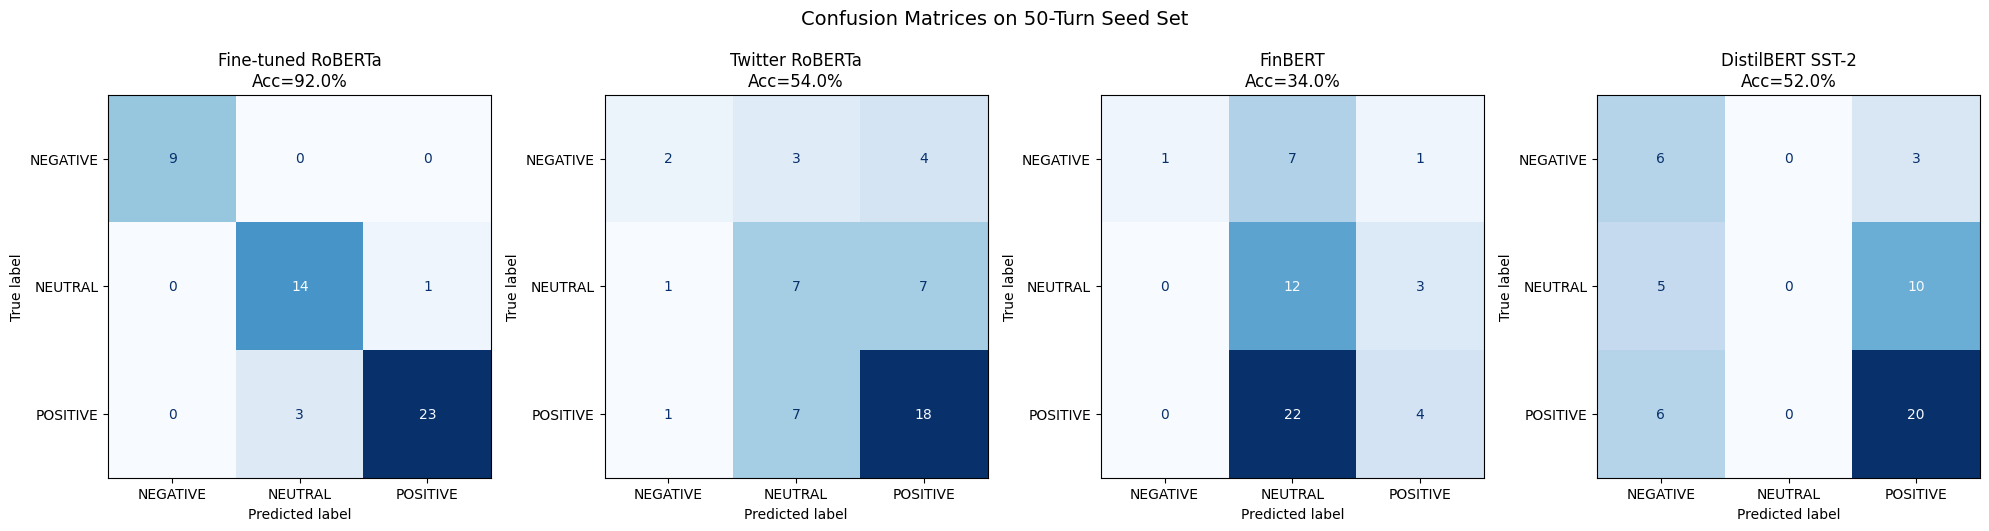

Saved: 03_confusion_matrices.png


In [5]:
models_to_plot = [
    ("fine_tuned", "Fine-tuned RoBERTa"),
    ("twitter",    "Twitter RoBERTa"),
    ("finbert",    "FinBERT"),
    ("distilbert", "DistilBERT SST-2"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (key, title) in zip(axes, models_to_plot):
    preds = results.get(key)
    if preds is None:
        ax.set_title(f"{title}\n(not available)")
        ax.axis("off")
        continue
    cm = confusion_matrix(gold, preds, labels=LABEL_ORDER)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    acc = accuracy_score(gold, preds)
    ax.set_title(f"{title}\nAcc={acc:.1%}")

plt.suptitle("Confusion Matrices on 50-Turn Seed Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("03_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 03_confusion_matrices.png")

## 5. Error Analysis - What Does the Fine-Tuned Model Still Miss?

In [6]:
ft_preds = results.get("fine_tuned")

if ft_preds is None:
    print("Fine-tuned model not available.")
else:
    # Per-class breakdown
    print("Classification report - Fine-tuned RoBERTa:")
    print(classification_report(gold, ft_preds, labels=LABEL_ORDER, zero_division=0))

    # Identify error patterns
    error_df = seed.copy()
    error_df["predicted"] = ft_preds
    error_df["correct"] = error_df["label"] == error_df["predicted"]

    errors = error_df[~error_df["correct"]].copy()
    print(f"\nTotal errors: {len(errors)} / {len(seed)}")

    if len(errors) > 0:
        print("\nError breakdown (gold -> predicted):")
        confusion = errors.groupby(["label", "predicted"]).size().reset_index(name="count")
        print(confusion.to_string(index=False))

Classification report - Fine-tuned RoBERTa:
              precision    recall  f1-score   support

    NEGATIVE       1.00      1.00      1.00         9
     NEUTRAL       0.82      0.93      0.88        15
    POSITIVE       0.96      0.88      0.92        26

    accuracy                           0.92        50
   macro avg       0.93      0.94      0.93        50
weighted avg       0.93      0.92      0.92        50


Total errors: 4 / 50

Error breakdown (gold -> predicted):
   label predicted  count
 NEUTRAL  POSITIVE      1
POSITIVE   NEUTRAL      3


## 6. Five Failure Examples

In [7]:
if ft_preds is None:
    print("Fine-tuned model not available.")
else:
    error_df = seed.copy()
    error_df["predicted"] = ft_preds
    errors = error_df[error_df["label"] != error_df["predicted"]]

    n_examples = min(5, len(errors))
    sample = errors.sample(n=n_examples, random_state=42) if len(errors) >= n_examples else errors

    print(f"Showing {n_examples} failure examples:\n")
    print("=" * 80)
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        print(f"Example {i}")
        print(f"  Speaker : {row['speaker']} ({row['role']}, {row['round']})")
        print(f"  Gold    : {row['label']}")
        print(f"  Pred    : {row['predicted']}")
        text = row["turn_text"]
        # Truncate long turns for readability
        if len(text) > 400:
            text = text[:400] + "..."
        print(f"  Text    : {text}")
        if pd.notna(row.get("label_notes")):
            print(f"  Notes   : {row['label_notes']}")
        print("-" * 80)

Showing 4 failure examples:

Example 1
  Speaker : TYLER HERRO (player, Finals)
  Gold    : NEUTRAL
  Pred    : POSITIVE
  Text    : Key to tonight was coming out hard with a lot of focus and energy. We knew it wasn't going to be easy and the next games we play aren't going to be easy either. And they're going to come with a lot more energy themselves, they're going to make some adjustments and it's all about how you respond. our backs are still against the wall and we got to respond.
  Notes   : Mixed: won but 'backs still against the wall' - resilient but under pressure
--------------------------------------------------------------------------------
Example 2
  Speaker : UDONIS HASLEM (player, ECF)
  Gold    : POSITIVE
  Pred    : NEUTRAL
  Text    : Â I just do what I'm called upon to do.Â I don't take very many shots.Â Sometimes it's not about shots for me.Â Sometimes it's about defensive rebounding. I took seven shots in the first two games, about three and a half shots per game.Â